In [1]:
!unzip /content/balanced_artifacts_dataset.zip -d /content/data

Streaming output truncated to the last 5000 lines.
  inflating: /content/data/Over Desaturation/1705985.png  
  inflating: /content/data/Over Desaturation/7033500.png  
  inflating: /content/data/Over Desaturation/2911640.png  
  inflating: /content/data/Over Desaturation/1666676.png  
  inflating: /content/data/Over Desaturation/2207725.png  
  inflating: /content/data/Over Desaturation/2207588.png  
  inflating: /content/data/Over Desaturation/5189261.png  
  inflating: /content/data/Over Desaturation/4930921.png  
  inflating: /content/data/Over Desaturation/2207720.png  
  inflating: /content/data/Over Desaturation/2209379.png  
  inflating: /content/data/Over Desaturation/3057414.png  
  inflating: /content/data/Over Desaturation/1705984.png  
  inflating: /content/data/Over Desaturation/2262406.png  
  inflating: /content/data/Over Desaturation/5103976.png  
  inflating: /content/data/Over Desaturation/745665.png  
  inflating: /content/data/Over Desaturation/225327.png  
  infla

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
import os
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [37]:
# Config & Paths
IMG_DIR = "/content/data"

NUM_CLASSES = 5
IMAGE_SIZE = 50                                 # Good balance for simple CNN + speed
BATCH_SIZE = 16
NUM_EPOCHS = 50
LEARNING_RATE = 0.001
NUM_WORKERS = 0 if torch.cuda.is_available() else 0

# Make sure paths exist


In [38]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset, random_split

# 1. Define separate transforms
# Training transform includes augmentations
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomRotation(15),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Validation transform is for inference (no augmentations)
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# 2. Define a Wrapper Class to apply transforms to Subsets
class TransformedSubset(torch.utils.data.Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)

# 3. Load the dataset WITHOUT transforms initially
# We load it with no transform so we can apply them later
full_dataset = datasets.ImageFolder(root=str(IMG_DIR))

# Extract class mapping
classes = full_dataset.classes
NUM_CLASSES = len(classes)
print(f"✅ Found {NUM_CLASSES} classes: {classes}")

# 4. Perform the Split
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# This returns Subset objects which are just indices of the original dataset
raw_train_subset, raw_val_subset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# 5. Apply the specific transforms using the wrapper
train_dataset = TransformedSubset(raw_train_subset, transform=train_transform)
val_dataset = TransformedSubset(raw_val_subset, transform=val_transform)

# 6. Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"✅ Setup complete!")
print(f"Total images: {len(full_dataset)}")
print(f"Training: {len(train_dataset)} | Validation: {len(val_dataset)}")

✅ Found 5 classes: ['Broken Line', 'Edge False Color', 'Over Desaturation', 'Saturated False Color', 'Smears']
✅ Setup complete!
Total images: 7025
Training: 5620 | Validation: 1405


In [40]:
class multi_class_model(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1: 50x50 -> 25x25
            nn.Conv2d(3, 20, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 2: 25x25 -> 12x12
            nn.Conv2d(20, 40, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            # Block 3: 12x12 -> 6x6
            nn.Conv2d(40, 80, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            # 80 filters * 6 * 6 spatial size = 2880
            nn.Linear(80 * 6 * 6, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Instantiate and verify
model = multi_class_model(num_classes=NUM_CLASSES).to(device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Total parameters: 406,093


In [41]:
# Loss, Optimizer & Scheduler

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)

In [42]:
train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}")
    for imgs, labels in loop:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, pred = torch.max(outputs, 1)
        total_train += labels.size(0)
        correct_train += (pred == labels).sum().item()
        loop.set_postfix(loss=running_loss/len(train_loader))


    train_losses.append(running_loss/len(train_loader))
    train_accs.append(correct_train/total_train)

    # --- VALIDATION PHASE (NEW) ---
    model.eval()
    running_test_loss, correct_test, total_test = 0.0, 0, 0

    with torch.no_grad(): # Disable gradient calculation for efficiency
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            running_test_loss += loss.item()
            _, pred = torch.max(outputs, 1)
            total_test += labels.size(0)
            correct_test += (pred == labels).sum().item()

    test_losses.append(running_test_loss / len(val_loader))
    test_accs.append(correct_test / total_test)

    print(f"Epoch {epoch+1}: Train Acc: {train_accs[-1]:.4f}, Test Acc: {test_accs[-1]:.4f}")

    model.eval()
    correct_test = 0





Epoch 1/46: 100%|██████████| 352/352 [00:06<00:00, 52.79it/s, loss=1.41]


Epoch 1: Train Acc: 0.4043, Test Acc: 0.4904


Epoch 2/46: 100%|██████████| 352/352 [00:06<00:00, 56.47it/s, loss=1.23]


Epoch 2: Train Acc: 0.4883, Test Acc: 0.5267


Epoch 3/46: 100%|██████████| 352/352 [00:06<00:00, 52.28it/s, loss=1.16]


...

Epoch 44: Train Acc: 0.7646, Test Acc: 0.7345


Epoch 45/46: 100%|██████████| 352/352 [00:06<00:00, 52.78it/s, loss=0.553]


Epoch 45: Train Acc: 0.7770, Test Acc: 0.7416


Epoch 46/46: 100%|██████████| 352/352 [00:06<00:00, 57.13it/s, loss=0.581]


Epoch 46: Train Acc: 0.7671, Test Acc: 0.7516


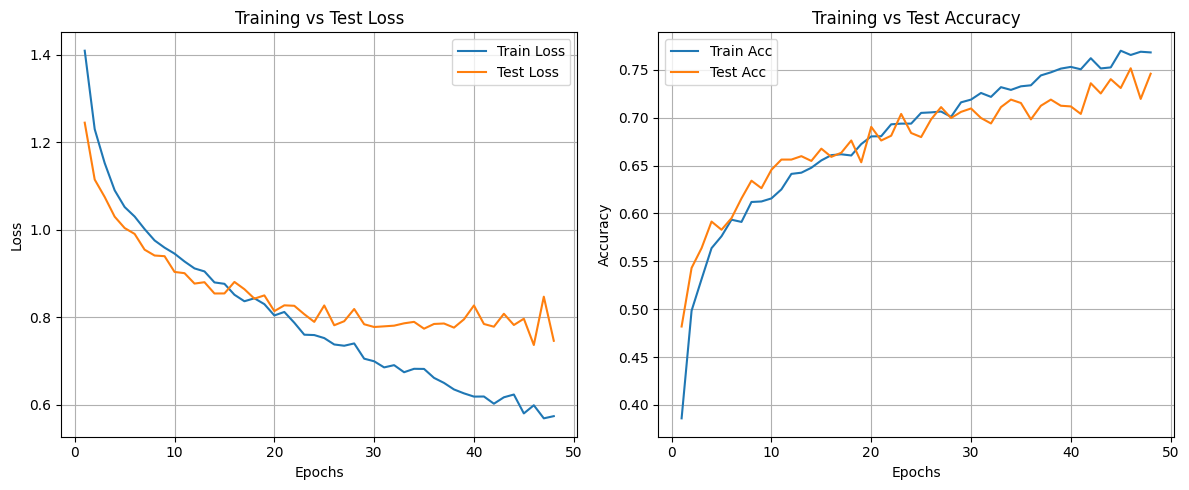

In [32]:
plt.figure(figsize=(12, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(range(1, NUM_EPOCHS+1), train_losses, label='Train Loss')
plt.plot(range(1, NUM_EPOCHS+1), test_losses, label='Test Loss')
plt.title('Training vs Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(range(1, NUM_EPOCHS+1), train_accs, label='Train Acc')
plt.plot(range(1, NUM_EPOCHS+1), test_accs, label='Test Acc')
plt.title('Training vs Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


📊 Accuracy of the model on the val images: 74.59%

📝 Classification Report:
                       precision    recall  f1-score   support

          Broken Line       0.74      0.78      0.76       260
     Edge False Color       0.72      0.73      0.72       287
    Over Desaturation       0.71      0.79      0.75       284
Saturated False Color       0.85      0.80      0.82       281
               Smears       0.73      0.64      0.68       293

             accuracy                           0.75      1405
            macro avg       0.75      0.75      0.75      1405
         weighted avg       0.75      0.75      0.75      1405



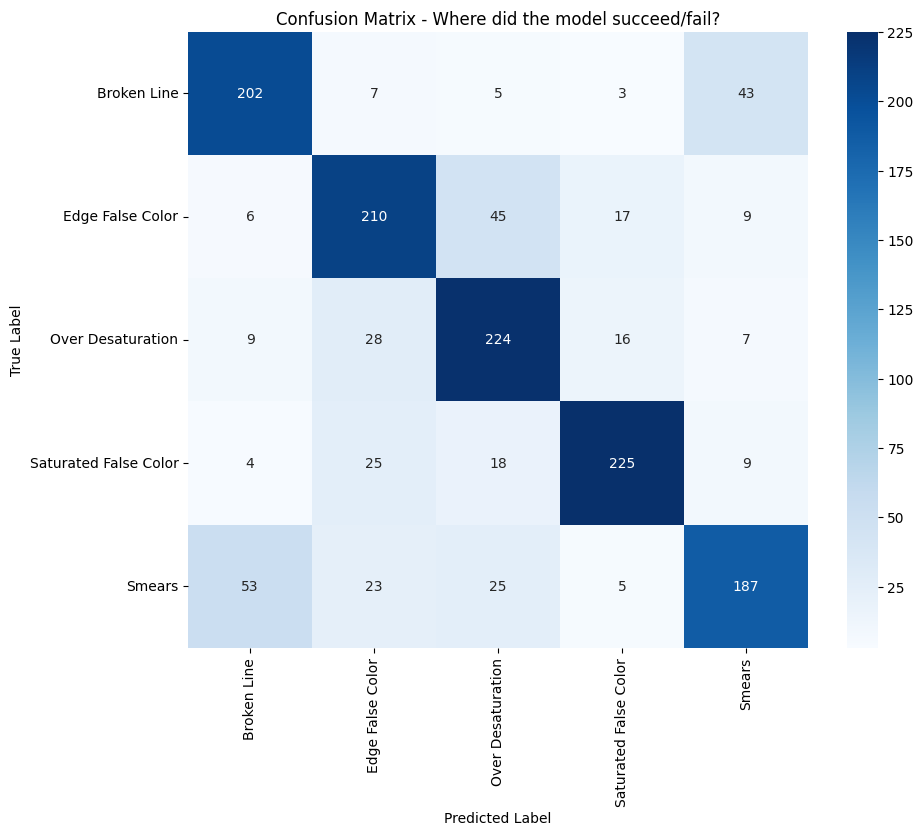

In [33]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

def evaluate_model(model, loader, device, class_names):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # חישוב אחוז הדיוק
    accuracy = 100 * correct / total
    print(f'\n📊 Accuracy of the model on the val images: {accuracy:.2f}%')

    # הדפסת דוח מפורט (Precision, Recall, F1-score)
    print("\n📝 Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    # יצירת מטריצת בלבול ויזואלית
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - Where did the model succeed/fail?')
    plt.show()

# הרצה של הפונקציה (וודא ש-val_loader ו-full_dataset קיימים)
# אם השתמשת ב-ImageFolder, השמות נמצאים ב-full_dataset.classes
evaluate_model(model, val_loader, device, full_dataset.classes)

In [43]:
#torch.save(model.state_dict(), 'multi_class_model_weights.pth')